In [1]:
!pip install akshare pandas numpy scikit-learn matplotlib tensorflow --upgrade


In [2]:
import akshare as ak
import pandas as pd
from datetime import datetime
import os

# 股票代码列表（已剔除科创板）
stock_codes = [
    "000718.SZ", "002108.SZ", "000100.SZ", "002031.SZ"
]

# 时间范围
start_date = "20210924"
end_date = datetime.today().strftime("%Y%m%d")

# 保存路径
save_path = "./data/"
os.makedirs(save_path, exist_ok=True)

# 字段标准化函数：中文 → 英文
def standardize_columns(df):
    column_mapping = {
        "日期": "Date",
        "股票代码": "Code",
        "开盘": "Open",
        "收盘": "Close",
        "最高": "High",
        "最低": "Low",
        "成交量": "Volume",
        "成交额": "Amount",
        "振幅": "Amplitude",
        "涨跌幅": "ChangePct",
        "涨跌额": "ChangeAmt",
        "换手率": "Turnover"
    }
    df.rename(columns=column_mapping, inplace=True)
    return df

# 主逻辑
for code in stock_codes:
    symbol = code.split('.')[0]  # 去掉后缀
    print(f"📈 正在处理：{code} → {symbol}")

    try:
        df = ak.stock_zh_a_hist(
            symbol=symbol,
            period="daily",
            start_date=start_date,
            end_date=end_date,
            adjust="qfq"
        )

        # 判断是否有有效数据
        if df is not None and not df.empty and len(df) > 0:
            df["股票代码"] = code
            df = standardize_columns(df)  # ✅ 字段标准化
            print(f"✅ {code} 获取成功，共 {len(df)} 条记录")
            print(f"📋 字段列表：{df.columns.tolist()}")

            # 保存为 CSV
            df.to_csv(f"{save_path}{code}.csv", index=False)
        else:
            print(f"⚠️ {code} 无数据，跳过保存")

    except Exception as e:
        print(f"❌ {code} 抓取失败：{e}")

    # 打印尾部数据用于调试
    if 'df' in locals() and not df.empty:
        print(df.tail())


📈 正在处理：000718.SZ → 000718
✅ 000718.SZ 获取成功，共 975 条记录
📋 字段列表：['Date', 'Code', 'Open', 'Close', 'High', 'Low', 'Volume', 'Amount', 'Amplitude', 'ChangePct', 'ChangeAmt', 'Turnover']
           Date       Code  Open  Close  High   Low   Volume        Amount  \
970  2025-09-24  000718.SZ  2.62   2.67  2.70  2.60  1515000  4.027877e+08   
971  2025-09-25  000718.SZ  2.64   2.59  2.67  2.58  1106669  2.890077e+08   
972  2025-09-26  000718.SZ  2.60   2.59  2.64  2.58   879080  2.299654e+08   
973  2025-09-29  000718.SZ  2.59   2.61  2.63  2.52   871585  2.248288e+08   
974  2025-09-30  000718.SZ  2.65   2.61  2.65  2.57   901481  2.344417e+08   

     Amplitude  ChangePct  ChangeAmt  Turnover  
970       3.82       1.91       0.05      6.64  
971       3.37      -3.00      -0.08      4.85  
972       2.32       0.00       0.00      3.85  
973       4.25       0.77       0.02      3.82  
974       3.07       0.00       0.00      3.95  
📈 正在处理：002108.SZ → 002108
✅ 002108.SZ 获取成功，共 975 条记录
📋 字段

In [ ]:
!pip install pandas numpy scikit-learn matplotlib tensorflow


In [3]:
# 这个是不能用的，点下面的运行单元格，这个是代码方便复制
import akshare as ak
import pandas as pd
from datetime import datetime
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import ModelCheckpoint

stock_codes =[
    "000718.SZ", "002108.SZ", "000100.SZ", "002031.SZ"
]

# 时间范围
start_date = "20210601"
end_date = datetime.today().strftime("%Y%m%d")

# 保存路径
save_path = "./data/"
os.makedirs(save_path, exist_ok=True)

# 字段标准化函数：中文 → 英文
def standardize_columns(df):
    column_mapping = {
        "日期": "Date",
        "股票代码": "Code",
        "开盘": "Open",
        "收盘": "Close",
        "最高": "High",
        "最低": "Low",
        "成交量": "Volume",
        "成交额": "Amount",
        "振幅": "Amplitude",
        "涨跌幅": "ChangePct",
        "涨跌额": "ChangeAmt",
        "换手率": "Turnover"
    }
    df.rename(columns=column_mapping, inplace=True)
    return df

# 主逻辑
for code in stock_codes:
    symbol = code.split('.')[0]  # 去掉后缀
    print(f"📈 正在处理：{code} → {symbol}")

    try:
        df = ak.stock_zh_a_hist(
            symbol=symbol,
            period="daily",
            start_date=start_date,
            end_date=end_date,
            adjust="qfq"
        )

        # 判断是否有有效数据
        if df is not None and not df.empty and len(df) > 0:
            df["股票代码"] = code
            df = standardize_columns(df)  # ✅ 字段标准化
            print(f"✅ {code} 获取成功，共 {len(df)} 条记录")
            print(f"📋 字段列表：{df.columns.tolist()}")

            # 保存为 CSV
            df.to_csv(f"{save_path}{code}.csv", index=False)
        else:
            print(f"⚠️ {code} 无数据，跳过保存")

    except Exception as e:
        print(f"❌ {code} 抓取失败：{e}")

    # 打印尾部数据用于调试
    if 'df' in locals() and not df.empty:
        print(df.tail())
def load_and_prepare_data(file_path):
    df = pd.read_csv(file_path)
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)
    df.set_index("Date", inplace=True)

    # 添加衍生特征
    df["MA5"] = df["Close"].rolling(window=5).mean()
    df["MA10"] = df["Close"].rolling(window=10).mean()
    df["EMA12"] = df["Close"].ewm(span=12, adjust=False).mean()
    df["EMA26"] = df["Close"].ewm(span=26, adjust=False).mean()
    df["MACD"] = df["EMA12"] - df["EMA26"]
    df["RSI"] = compute_rsi(df["Close"], window=14)
    df["Return_1d"] = df["Close"].pct_change()
    df["Volatility_5d"] = df["Close"].rolling(window=5).std()
    df["Weekday"] = df.index.weekday
    df["IsMonthEnd"] = df.index.is_month_end.astype(int)

    # 去除空值
    df.dropna(inplace=True)

    # 特征选择
    features = [
        "Open", "High", "Low", "Close", "Volume", "Amount", "Turnover",
        "MA5", "MA10", "EMA12", "EMA26", "MACD", "RSI",
        "Return_1d", "Volatility_5d", "Weekday", "IsMonthEnd"
    ]

    scaler = MinMaxScaler()
    df_scaled = scaler.fit_transform(df[features])

    return df_scaled, df["Close"].values, scaler
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi
def create_sequences(data_scaled, close_prices, window_size=60, pred_size=15):
    """
    构造 LSTM 所需的时间序列样本。
    参数：
        data_scaled: 标准化后的特征数据（二维数组）
        close_prices: 原始收盘价序列（用于预测目标）
        window_size: 输入窗口长度（如 30、60、90）
        pred_size: 预测天数（默认 15）
    返回：
        X: 输入序列（形状：[样本数, window_size, 特征数]）
        y: 目标序列（形状：[样本数, pred_size]）
    """
    X, y = [], []
    for i in range(len(data_scaled) - window_size - pred_size + 1):
        X.append(data_scaled[i:i+window_size])
        y.append(close_prices[i+window_size:i+window_size+pred_size])
    return np.array(X), np.array(y)
# 定义窗口长度列表
window_sizes = [30, 60, 90]

# 存储所有股票的训练样本
sequences = {}

for file, df in scaled_stock_data.items():
    stock_sequences = {}

    # 提取标准化特征和原始收盘价
    data_scaled = df.values  # 标准化后的特征数据
    close_prices = df["Close"].values  # 原始收盘价（用于预测）

    for window_size in window_sizes:
        # 构造训练样本
        X, y = create_sequences(data_scaled, close_prices, window_size=window_size, pred_size=15)
        stock_sequences[window_size] = (X, y)

        # 打印样本维度信息，便于调试和教学展示
        print(f"✅ 股票：{file} | 窗口：{window_size} → X: {X.shape}, y: {y.shape}")

    # 保存当前股票的所有窗口样本
    sequences[file] = stock_sequences


def build_lstm_model(input_shape, output_size=15):
    """
    构建双层 LSTM 模型。
    参数：
        input_shape: 输入数据的形状（如 [窗口长度, 特征数]）
        output_size: 预测输出的天数（默认 15）
    返回：
        编译后的 Keras 模型
    """
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=input_shape))  # 第一层 LSTM
    model.add(LSTM(32))  # 第二层 LSTM
    model.add(Dense(output_size))  # 输出层，预测未来15天收盘价
    model.compile(optimizer='adam', loss='mse')
    return model
def train_lstm_model(X, y, input_shape, model_path):
    """
    训练 LSTM 模型并保存最优权重。
    参数：
        X, y: 训练数据
        input_shape: 输入维度
        model_path: 模型保存路径
    返回：
        训练后的模型
    """
    model = build_lstm_model(input_shape)
    checkpoint = ModelCheckpoint(model_path, monitor='loss', save_best_only=True, verbose=1)
    model.fit(X, y, epochs=50, batch_size=32, callbacks=[checkpoint], verbose=0)
    return model


import matplotlib.pyplot as plt

def predict_and_plot(model, scaled_data, scaler, window_size, stock_code):
    """
    使用训练好的模型预测未来15天收盘价，并绘图展示。
    参数：
        model: 已训练好的 LSTM 模型
        scaled_data: 标准化后的特征数据
        scaler: 用于反归一化的 scaler 对象
        window_size: 输入窗口长度
        stock_code: 当前股票代码
    """
    last_window = scaled_data[-window_size:]  # 取最近的窗口数据
    prediction = model.predict(np.expand_dims(last_window, axis=0))[0]  # 预测未来15天

    # 构造反归一化输入（只恢复 Close 一列）
    dummy = np.zeros((15, scaled_data.shape[1]))
    dummy[:, -1] = prediction  # 假设最后一列是 Close
    recovered = scaler.inverse_transform(dummy)[:, -1]

    # 绘图展示
    plt.figure(figsize=(10, 4))
    plt.plot(range(1, 16), recovered, marker='o', label="预测收盘价")
    plt.title(f"{stock_code} - 未来15天收盘价预测")
    plt.xlabel("未来天数")
    plt.ylabel("收盘价")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return recovered




📈 正在处理：000718.SZ → 000718
✅ 000718.SZ 获取成功，共 1055 条记录
📋 字段列表：['Date', 'Code', 'Open', 'Close', 'High', 'Low', 'Volume', 'Amount', 'Amplitude', 'ChangePct', 'ChangeAmt', 'Turnover']
            Date       Code  Open  Close  High   Low   Volume        Amount  \
1050  2025-09-24  000718.SZ  2.62   2.67  2.70  2.60  1515000  4.027877e+08   
1051  2025-09-25  000718.SZ  2.64   2.59  2.67  2.58  1106669  2.890077e+08   
1052  2025-09-26  000718.SZ  2.60   2.59  2.64  2.58   879080  2.299654e+08   
1053  2025-09-29  000718.SZ  2.59   2.61  2.63  2.52   871585  2.248288e+08   
1054  2025-09-30  000718.SZ  2.65   2.61  2.65  2.57   901481  2.344417e+08   

      Amplitude  ChangePct  ChangeAmt  Turnover  
1050       3.82       1.91       0.05      6.64  
1051       3.37      -3.00      -0.08      4.85  
1052       2.32       0.00       0.00      3.85  
1053       4.25       0.77       0.02      3.82  
1054       3.07       0.00       0.00      3.95  
📈 正在处理：002108.SZ → 002108
✅ 002108.SZ 获取成功，共

NameError: name 'scaled_stock_data' is not defined

In [4]:
features = [
    "Open", "High", "Low", "Close", "Volume", "Amount", "Turnover",
    "MA5", "MA10", "EMA12", "EMA26", "MACD", "RSI",
    "Return_1d", "Volatility_5d", "Weekday", "IsMonthEnd"
]


In [5]:
results = {}  # 用于保存每支股票的最佳窗口预测结果

for stock_code, stock_windows in sequences.items():
    print(f"\n📊 正在处理股票：{stock_code}")
    best_loss = float("inf")
    best_window = None
    best_model = None

    for window_size, (X, y) in stock_windows.items():
        model_path = f"./models/{stock_code}_win{window_size}.h5"

        # 训练模型并保存最优权重
        model = train_lstm_model(X, y, input_shape=X.shape[1:], model_path=model_path)
        loss = model.evaluate(X, y, verbose=0)

        print(f"✅ 窗口 {window_size} 训练完成，loss={loss:.4f}")
        if loss < best_loss:
            best_loss = loss
            best_window = window_size
            best_model = model

    # 使用最佳窗口模型进行预测并绘图
    scaled_data = scaled_stock_data[stock_code].values
    scaler = MinMaxScaler().fit(scaled_data)  # 重新拟合用于反归一化
    prediction = predict_and_plot(best_model, scaled_data, scaler, best_window, stock_code)

    # 保存结果
    results[stock_code] = {
        "window": best_window,
        "loss": best_loss,
        "prediction": prediction
    }


In [6]:
import os
print(os.listdir("data"))


['000718.SZ.csv', '002031.SZ.csv', '002108.SZ.csv', '000100.SZ.csv']


In [8]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# RSI 函数
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# 数据预处理函数
def load_and_prepare_data(file_path):
    df = pd.read_csv(file_path)
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)
    df.set_index("Date", inplace=True)

    # 添加衍生特征
    df["MA5"] = df["Close"].rolling(window=5).mean()
    df["MA10"] = df["Close"].rolling(window=10).mean()
    df["EMA12"] = df["Close"].ewm(span=12, adjust=False).mean()
    df["EMA26"] = df["Close"].ewm(span=26, adjust=False).mean()
    df["MACD"] = df["EMA12"] - df["EMA26"]
    df["RSI"] = compute_rsi(df["Close"], window=14)
    df["Return_1d"] = df["Close"].pct_change()
    df["Volatility_5d"] = df["Close"].rolling(window=5).std()
    df["Weekday"] = df.index.weekday
    df["IsMonthEnd"] = df.index.is_month_end.astype(int)
    df.dropna(inplace=True)

    # 特征选择并标准化
    features = [
        "Open", "High", "Low", "Close", "Volume", "Amount", "Turnover",
        "MA5", "MA10", "EMA12", "EMA26", "MACD", "RSI",
        "Return_1d", "Volatility_5d", "Weekday", "IsMonthEnd"
    ]
    scaler = MinMaxScaler()
    df_scaled = scaler.fit_transform(df[features])
    return df_scaled, df["Close"].values, scaler

# 加载所有股票数据
data_dir = "data"
scaled_stock_data = {}

for file in os.listdir(data_dir):
    if file.endswith(".csv"):
        code = file.replace(".csv", "")
        path = os.path.join(data_dir, file)
        try:
            scaled_data, close_prices, scaler = load_and_prepare_data(path)
            df_scaled = pd.DataFrame(scaled_data)
            df_scaled["Close"] = close_prices  # 保留原始收盘价用于预测
            scaled_stock_data[code] = df_scaled
            print(f"✅ 已处理：{code}，样本数：{len(df_scaled)}")
        except Exception as e:
            print(f"❌ 处理失败：{code} → {e}")


✅ 已处理：000718.SZ，样本数：1042
✅ 已处理：002031.SZ，样本数：1042
✅ 已处理：002108.SZ，样本数：1042
✅ 已处理：000100.SZ，样本数：1042



📊 正在处理股票：000718.SZ


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


✅ 窗口 30 训练完成，loss=0.0371


✅ 窗口 60 训练完成，loss=0.0353


✅ 窗口 90 训练完成，loss=0.0370
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 26469 (\N{CJK UNIFIED IDEOGRAPH-6765}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 30424 (\N{CJK UNIFIED IDEOGRAPH-76D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missi

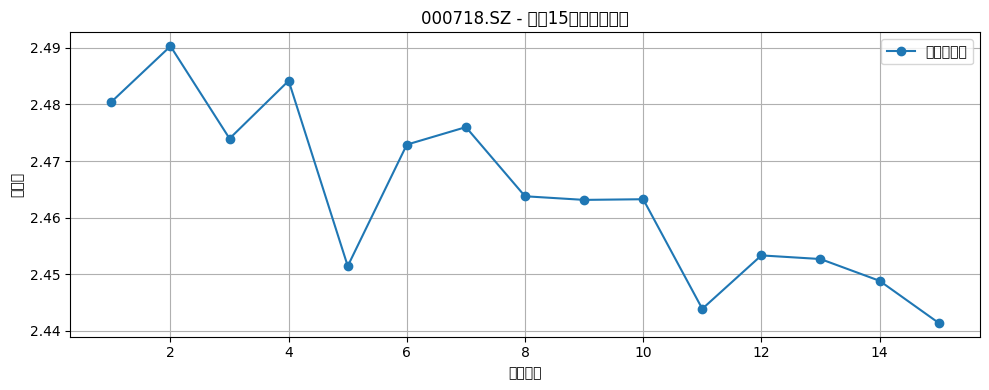

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



📊 正在处理股票：002031.SZ


✅ 窗口 30 训练完成，loss=0.1621


✅ 窗口 60 训练完成，loss=0.2315


✅ 窗口 90 训练完成，loss=0.1558
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 26469 (\N{CJK UNIFIED IDEOGRAPH-6765}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 30424 (\N{CJK UNIFIED IDEOGRAPH-76D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missi

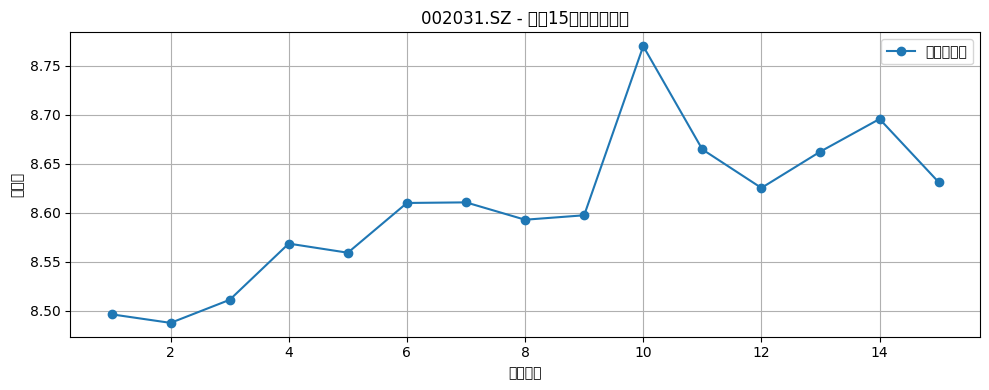


📊 正在处理股票：002108.SZ


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


✅ 窗口 30 训练完成，loss=0.0968


✅ 窗口 60 训练完成，loss=0.0691


✅ 窗口 90 训练完成，loss=0.0496
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 26469 (\N{CJK UNIFIED IDEOGRAPH-6765}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 30424 (\N{CJK UNIFIED IDEOGRAPH-76D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missi

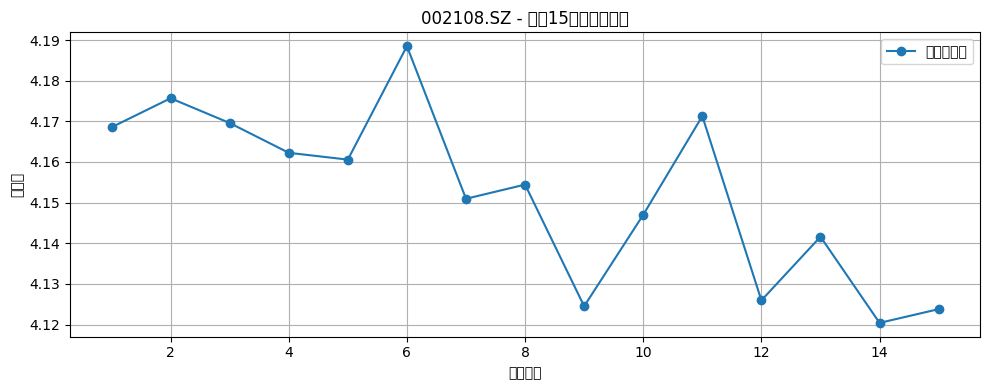


📊 正在处理股票：000100.SZ


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


✅ 窗口 30 训练完成，loss=0.0477


✅ 窗口 60 训练完成，loss=0.0375


✅ 窗口 90 训练完成，loss=0.0469
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 26469 (\N{CJK UNIFIED IDEOGRAPH-6765}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 30424 (\N{CJK UNIFIED IDEOGRAPH-76D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189401619.py:37: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missi

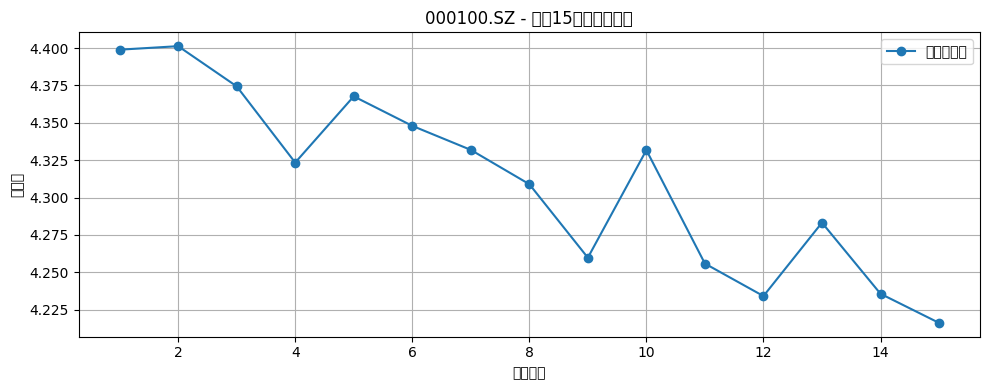

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt

# 构造训练样本函数
def create_sequences(data_scaled, close_prices, window_size=60, pred_size=15):
    X, y = [], []
    for i in range(len(data_scaled) - window_size - pred_size + 1):
        X.append(data_scaled[i:i+window_size])
        y.append(close_prices[i+window_size:i+window_size+pred_size])
    return np.array(X), np.array(y)

# 构建模型函数
def build_lstm_model(input_shape, output_size=15):
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=input_shape))
    model.add(LSTM(32))
    model.add(Dense(output_size))
    model.compile(optimizer='adam', loss='mse')
    return model

# 预测并绘图函数
def predict_and_plot(model, scaled_data, scaler, window_size, stock_code):
    last_window = scaled_data[-window_size:]
    prediction = model.predict(np.expand_dims(last_window, axis=0))[0]
    dummy = np.zeros((15, scaled_data.shape[1]))
    dummy[:, -1] = prediction
    recovered = scaler.inverse_transform(dummy)[:, -1]
    plt.figure(figsize=(10, 4))
    plt.plot(range(1, 16), recovered, marker='o', label="预测收盘价")
    plt.title(f"{stock_code} - 未来15天收盘价预测")
    plt.xlabel("未来天数")
    plt.ylabel("收盘价")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    return recovered

# 执行训练与预测
window_sizes = [30, 60, 90]
results = {}

for stock_code, df_scaled in scaled_stock_data.items():
    print(f"\n📊 正在处理股票：{stock_code}")
    scaled_data = df_scaled.drop(columns=["Close"]).values
    close_prices = df_scaled["Close"].values
    best_loss = float("inf")
    best_window = None
    best_model = None

    for window_size in window_sizes:
        X, y = create_sequences(scaled_data, close_prices, window_size=window_size, pred_size=15)
        if len(X) == 0:
            print(f"⚠️ 样本不足，跳过窗口 {window_size}")
            continue
        model = build_lstm_model(X.shape[1:])
        checkpoint = ModelCheckpoint(f"models/{stock_code}_win{window_size}.h5", monitor='loss', save_best_only=True, verbose=0)
        model.fit(X, y, epochs=50, batch_size=32, callbacks=[checkpoint], verbose=0)
        loss = model.evaluate(X, y, verbose=0)
        print(f"✅ 窗口 {window_size} 训练完成，loss={loss:.4f}")
        if loss < best_loss:
            best_loss = loss
            best_window = window_size
            best_model = model

    # 预测并绘图
    scaler = MinMaxScaler().fit(scaled_data)
    prediction = predict_and_plot(best_model, scaled_data, scaler, best_window, stock_code)
    results[stock_code] = {
        "window": best_window,
        "loss": best_loss,
        "prediction": prediction
    }
